# Cole's code for the galaxies project!

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from routines import obs_sdss
import os
import urllib.request 
from astropy.io import fits 
from colossus.cosmology import cosmology
import numpy as np



In [21]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from routines import common as cmn

# Plotting settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Automatically reload code imported from changed python files
%reload_ext autoreload
%autoreload 2

In [22]:
from routines import obs_sdss

d_upenn = obs_sdss.loadUPennCatalog()

print('Found %d galaxies with the following fields:' % (len(d_upenn)))
for k in d_upenn.dtype.names:
    print(k)

Found 652773 galaxies with the following fields:
SexMag_r
SexMag_Err_r
SexHrad_r
SexSky_r
num_targets_r
num_neighborfit_r
AperRad_r
C_r
C_err_r
A_r
A_err_r
S_r
S_err_r
G_r
M20_r
extinction_r
dismod_r
kpc_per_arcsec_r
Vmax_r
SN_r
kcorr_r
SexMag_g
SexMag_Err_g
SexHrad_g
SexSky_g
num_targets_g
num_neighborfit_g
AperRad_g
C_g
C_err_g
A_g
A_err_g
S_g
S_err_g
G_g
M20_g
extinction_g
dismod_g
kpc_per_arcsec_g
Vmax_g
SN_g
kcorr_g
m_tot_r
m_aper_r
BT_r
r_tot_r
ba_tot_r
BT_aper_r
xctr_bulge_r
xctr_bulge_err_r
yctr_bulge_r
yctr_bulge_err_r
m_bulge_r
m_bulge_err_r
r_bulge_r
r_bulge_err_r
n_bulge_r
n_bulge_err_r
ba_bulge_r
ba_bulge_err_r
pa_bulge_r
pa_bulge_err_r
xctr_disk_r
xctr_disk_err_r
yctr_disk_r
yctr_disk_err_r
m_disk_r
m_disk_err_r
r_disk_r
r_disk_err_r
n_disk_r
n_disk_err_r
ba_disk_r
ba_disk_err_r
pa_disk_r
pa_disk_err_r
GalSky_r
GalSky_err_r
chi2nu_r
finalflag_r
autoflag_r
pyflag_r
pyfitflag_r
m_tot_g
m_aper_g
BT_g
r_tot_g
ba_tot_g
BT_aper_g
xctr_bulge_g
xctr_bulge_err_g
yctr_bulge_g
yctr_

In [23]:
# MODIFIED VERSION OF getSdssSpectrum: Previously, the URL format was old and not cooperating.
sdss_spec_dir = "./sdss_spectra/"

def getSdssSpectrum(obj_id, plate, mjd, fiber):
    if not os.path.exists(sdss_spec_dir):
        os.mkdir(sdss_spec_dir)

    fn = sdss_spec_dir + '%d_plate_%d_mjd_%d_fiber_%d.fit' % (obj_id, plate, mjd, fiber)

    if not os.path.exists(fn):
        url = f"https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/{plate:04d}/spec-{plate:04d}-{mjd}-{fiber:04d}.fits"
        print("Downloading:", url)

        try:
            urllib.request.urlretrieve(url, fn)
        except urllib.error.HTTPError:
            print(f"Missing spectrum: plate={plate}, mjd={mjd}, fiber={fiber}")
            return None, None
    
    try:
        hdu = fits.open(fn)
        data = hdu[1].data
        lam = 10**data['loglam']
        spectrum = data['flux']
        return lam, spectrum
    except:
        return None, None


obs_sdss.getSdssSpectrum = getSdssSpectrum

In [24]:
data = obs_sdss.loadSdssSpecSample()
print('Found %d galaxies with the following fields:' % (len(data)))
for k in data.dtype.names:
    print(k)

Found 673232 galaxies with the following fields:
ra
dec
mjd
plate
fiberID
class
z
zErr
rChi2
velDisp
velDispErr
extinction_u
extinction_g
extinction_r
extinction_i
extinction_z
fiberMag_u
fiberMag_g
fiberMag_r
fiberMag_i
fiberMag_z
modelMag_u
modelMag_g
modelMag_r
modelMag_i
modelMag_z
cmodelMag_u
cmodelMag_g
cmodelMag_r
cmodelMag_i
cmodelMag_z
phioffset_r
fracdeV_r
deVRad_r
deVRadErr_r
deVAB_r
deVABErr_r
deVPhi_r
lnLDeV_r
deVMag_r
deVMagErr_r
expRad_r
expRadErr_r
expAB_r
expABErr_r
expPhi_r
lnLExp_r
expMag_r
expMagErr_r
petroMag_u
petroMag_g
petroMag_r
petroMag_i
petroMag_z
petroRad_u
petroRad_g
petroRad_r
petroRad_i
petroRad_z
petroR50_r
petroR90_r
petroR50Err_r
petroR90Err_r
h_alpha_flux
h_alpha_flux_err
oiii_5007_flux
oiii_5007_flux_err
d4000
d4000_err
bptclass
lgm_tot_p50
sfr_tot_p50
objID
specObjID


In [25]:
# Load catalog and use mag cutoff
bright = d_upenn[d_upenn['m_tot_r'] < 14.5]

# Using the meaning of life for the seeeeeeeeeeedddddd
np.random.seed(57)
idx = np.random.choice(len(bright), size=2000, replace=False)
sample = bright[idx]


# Grab the spectrum for each galaxy and compute
Dn_obs = []
Hd_obs = []

for gal in sample:
    wave_obs, flux_obs = getSdssSpectrum(0, gal['plate'], gal['mjd'], gal['fiberid'])

    if wave_obs is None or flux_obs is None:
        continue
    
    z = gal['z']
    
    # Rest-frame correction
    wave_rest = wave_obs / (1 + z)
    flux_rest = flux_obs 

Downloading: https://data.sdss.org/sas/dr16/sdss/spectro/redux/26/spectra/lite/2516/spec-2516-54240-0589.fits
Missing spectrum: plate=2516, mjd=54240, fiber=589


-23.62495641770895
-21.71228133878869
-20.702348019416963
-22.541428733848637
-20.376069398023994
-19.780494641819992
-24.059598383160118
-22.250024400090044
-22.25969033006083
-21.937584386596708
-22.334932793068155
-20.53612493501086
-22.965818547775285
-21.955161941627846
-22.61814795708898
-23.597669274056198
-21.0055340803879
-22.811599696161434
-23.03287163725982
-20.657627509669467
-21.99345292595303
-23.17482325813895
-18.119221391723578
-21.880287891385063
-20.409616902050704
-22.511782138936603
-23.358497963657925
-20.869576464687228
-23.08216220001805
-22.80565832396214
-21.83583114536559
-23.32069451725051
-21.320570688468568
-22.50645285096278
-20.17187289091144
-22.182773206664155
-21.084140569920216
-21.059906724580877
-22.80613180633787
-23.20202980644519
-21.465847719308304
-20.425929364522165
-21.277458282713262
-21.08747259168349
-23.81336506023528
-21.53345569122846
-22.68908856668391
-21.734060409470864
-20.731978980185286
-22.852019331713425
-21.545396552492775
-2

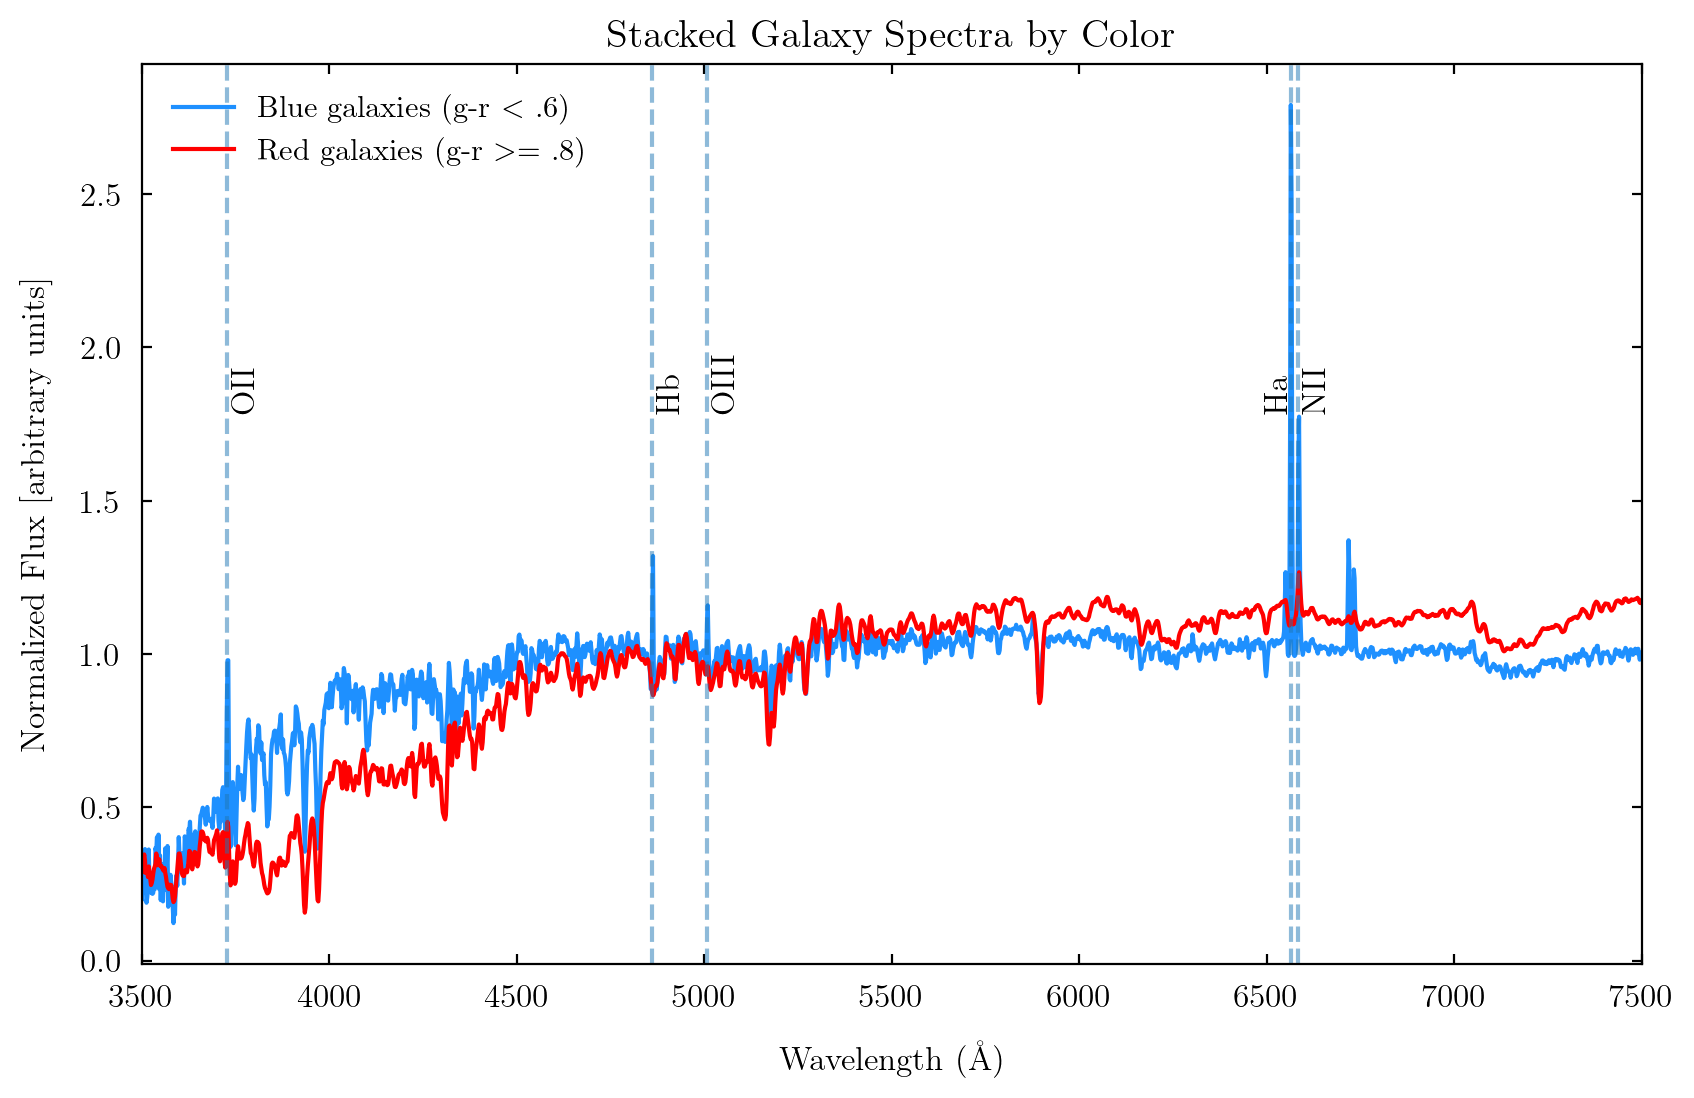

In [ ]:
rest_spectra = []
colors = []
M_r_list = []

from routines import obs_utils

for gal in sample:
    wave_obs, flux_obs = getSdssSpectrum(0,
        gal['plate'], gal['mjd'], gal['fiberid']
    )

    if wave_obs is None or flux_obs is None:
        continue

    z = gal['z']

    wave_rest = wave_obs / (1 + z)
    flux_rest = flux_obs

    rest_spectra.append((wave_rest, flux_rest))
    colors.append(gal['m_tot_g'] - gal['m_tot_r'])

    cosmo = cosmology.getCurrent()

    mg = gal['m_tot_g'] - gal['extinction_g']
    mr = gal['m_tot_r'] - gal['extinction_r']

    gr_uncor = mg - mr

    K_r_gr = obs_utils.kCorrection('r', z, 'g-r', gr_uncor)
    #print("K-correction (r-band):", K_r_gr)

    M_r = gal['m_tot_r'] - gal['extinction_r'] - cosmo.distanceModulus(z) - K_r_gr
    print(M_r)
    M_r_list.append(M_r)

# Common wavelength grid
wave_grid = np.linspace(3500, 7500, 2000)


# Process spectrum in rest frame
def process_spectrum_rest(wave_rest, flux_rest):
    # Interpolate onto common grid
    f = interp1d(wave_rest, flux_rest, bounds_error=False, fill_value=np.nan)
    flux_interp = f(wave_grid)

    if np.sum(np.isfinite(flux_interp)) < 100:
        return None

    # Normalize (continuum region)
    mask = (wave_grid > 5000) & (wave_grid < 5500)
    norm = np.nanmedian(flux_interp[mask])

    if not np.isfinite(norm) or norm == 0:
        return None

    return flux_interp / norm


# Stack spectra
def stack_precomputed(spectra_list, max_gal=2000):
    stack = []

    for wave_rest, flux_rest in spectra_list[:max_gal]:
        spec = process_spectrum_rest(wave_rest, flux_rest)

        if spec is not None:
            stack.append(spec)
    print("stack size:", len(stack))
    return np.nanmedian(np.array(stack), axis=0)


# Define bins (color)
blue_spectra = [
    rest_spectra[i] for i in range(len(colors)) if colors[i] < 0.6
]

red_spectra = [
    rest_spectra[i] for i in range(len(colors)) if colors[i] >= 0.8
]


# Compute stacks
blue_stack = stack_precomputed(blue_spectra)
red_stack  = stack_precomputed(red_spectra)


def compute_Dn4000(wave, flux):
    blue = (wave >= 3850) & (wave <= 3950)
    red  = (wave >= 4000) & (wave <= 4100)
    
    F_blue = np.mean(flux[blue])
    F_red  = np.mean(flux[red])
    
    return F_red / F_blue


def compute_HdeltaA(wave, flux):
    b1 = (wave >= 4030) & (wave <= 4082)
    b2 = (wave >= 4122) & (wave <= 4170)
    line = (wave >= 4082) & (wave <= 4122)
    
    # Continuum estimate
    F_cont = 0.5 * (np.mean(flux[b1]) + np.mean(flux[b2]))
    
    # Equivalent width (Å)
    dlam = np.diff(wave[line])
    flux_line = flux[line][:-1]
    
    return np.sum((1 - flux_line / F_cont) * dlam)



print("D4000 (blue galaxies):", compute_Dn4000(wave_grid, blue_stack))
print("D4000 (red galaxies):", compute_Dn4000(wave_grid, red_stack))



# Plot spectra + lines
plt.figure(figsize=(10,6))

if blue_stack is not None:
    plt.plot(wave_grid, blue_stack, label='Blue galaxies (g-r $<$ .6)', color = 'dodgerblue')

if red_stack is not None:
    plt.plot(wave_grid, red_stack, label='Red galaxies (g-r $>=$ .8)', color = 'red')


# --- Key spectral lines ---
lines = {
    "OII": 3727,
    "Hb": 4861,
    "OIII": 5007,
}

for name, wl in lines.items():
    plt.axvline(wl, linestyle='--', alpha=0.5)
    plt.text(wl + 10, 1.8, name, rotation=90)

plt.axvline(6563, linestyle='--', alpha=0.5)
plt.text(6563 - 70, 1.8, 'Ha', rotation=90)

plt.axvline(6584, linestyle='--', alpha=0.5)
plt.text(6584 + 10, 1.8, 'NII', rotation=90)


plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux [arbitrary units]')
plt.title('Stacked Galaxy Spectra by Color')
plt.legend()
plt.xlim(3500, 7500)
plt.savefig('stacked_spectra_color_bins.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
M_r_arr = np.array(M_r_list) 


# Define magnitude bins (Chatgpt helped with this exact flow)
bright_spectra = [rest_spectra[i] for i, Mr in enumerate(M_r_arr) if Mr < -22]

faint_spectra = [rest_spectra[i] for i, Mr in enumerate(M_r_arr) if Mr >= -22]


# Stack function
def stack_precomputed_with_count(spectra_list, max_gal=2000):
    stack = []
    used = 0

    for wave_rest, flux_rest in spectra_list[:max_gal]:
        spec = process_spectrum_rest(wave_rest, flux_rest)

        if spec is not None:
            stack.append(spec)
            used += 1

    return np.nanmedian(np.vstack(stack), axis=0), used


# Compute stacks
bright_stack, bright_used = stack_precomputed_with_count(bright_spectra)
faint_stack, faint_used   = stack_precomputed_with_count(faint_spectra)


# Print counts
print(f"Bright bin: {len(bright_spectra)} galaxies total, {bright_used} stacked")
print(f"Faint bin:  {len(faint_spectra)} galaxies total, {faint_used} stacked")



def measure_line_flux(wave, flux, line_center, window=5):

    line_mask = (wave > line_center - window) & (wave < line_center + window)

    # I asked chatgpt to help with the syntax for this mask

    cont_left = np.nanmedian(flux[(wave > line_center - 80) & (wave < line_center - 30)])
    cont_right = np.nanmedian(flux[(wave > line_center + 30) & (wave < line_center + 80)])

    cont = 0.5 * (cont_left + cont_right)

    line_flux = flux[line_mask] - cont

    flux_val = np.trapz(line_flux, wave[line_mask])

    if flux_val <= 0:
        return np.nan

    return flux_val


def compute_line_ratios(wave, flux):
    Hb   = measure_line_flux(wave, flux, 4861)
    OIII = measure_line_flux(wave, flux, 5007)
    Ha   = measure_line_flux(wave, flux, 6563)
    NII  = measure_line_flux(wave, flux, 6584)
    OII = measure_line_flux(wave, flux, 3727)

    ratios = {}

    if np.abs(Hb) > 1e-3 and np.abs(Ha) > 1e-3:
        ratios['OIII_Hb'] = np.log10(OIII / Hb)
        ratios['NII_Ha']  = np.log10(NII / Ha)
        ratios['OII_OIII'] = np.log10(OII / OIII)

    return ratios


# Apply to stacked spectra

print("Bright galaxy line ratios:", compute_line_ratios(wave_grid, bright_stack))
print("Faint galaxy line ratios:", compute_line_ratios(wave_grid, faint_stack))
print("Blue galaxy line ratios:", compute_line_ratios(wave_grid, blue_stack))
print("Red galaxy line ratios:", compute_line_ratios(wave_grid, red_stack))


Bright bin: 926 galaxies total, 926 stacked
Faint bin:  1073 galaxies total, 1073 stacked
Bright galaxy line ratios: {}
Faint galaxy line ratios: {}
Blue galaxy line ratios: {'OIII_Hb': 0.035169054515432126, 'NII_Ha': -0.39115275819937395, 'OII_OIII': 0.6150597440694421}
Red galaxy line ratios: {}


/var/folders/lx/ftzs4lrn0cgbwjrztzt0n5w00000gn/T/ipykernel_1475/3609209689.py:60: RuntimeWarning: All-NaN slice encountered
  cont_left = np.nanmedian(flux[(wave > line_center - 80) & (wave < line_center - 30)])
/var/folders/lx/ftzs4lrn0cgbwjrztzt0n5w00000gn/T/ipykernel_1475/3609209689.py:61: RuntimeWarning: All-NaN slice encountered
  cont_right = np.nanmedian(flux[(wave > line_center + 30) & (wave < line_center + 80)])


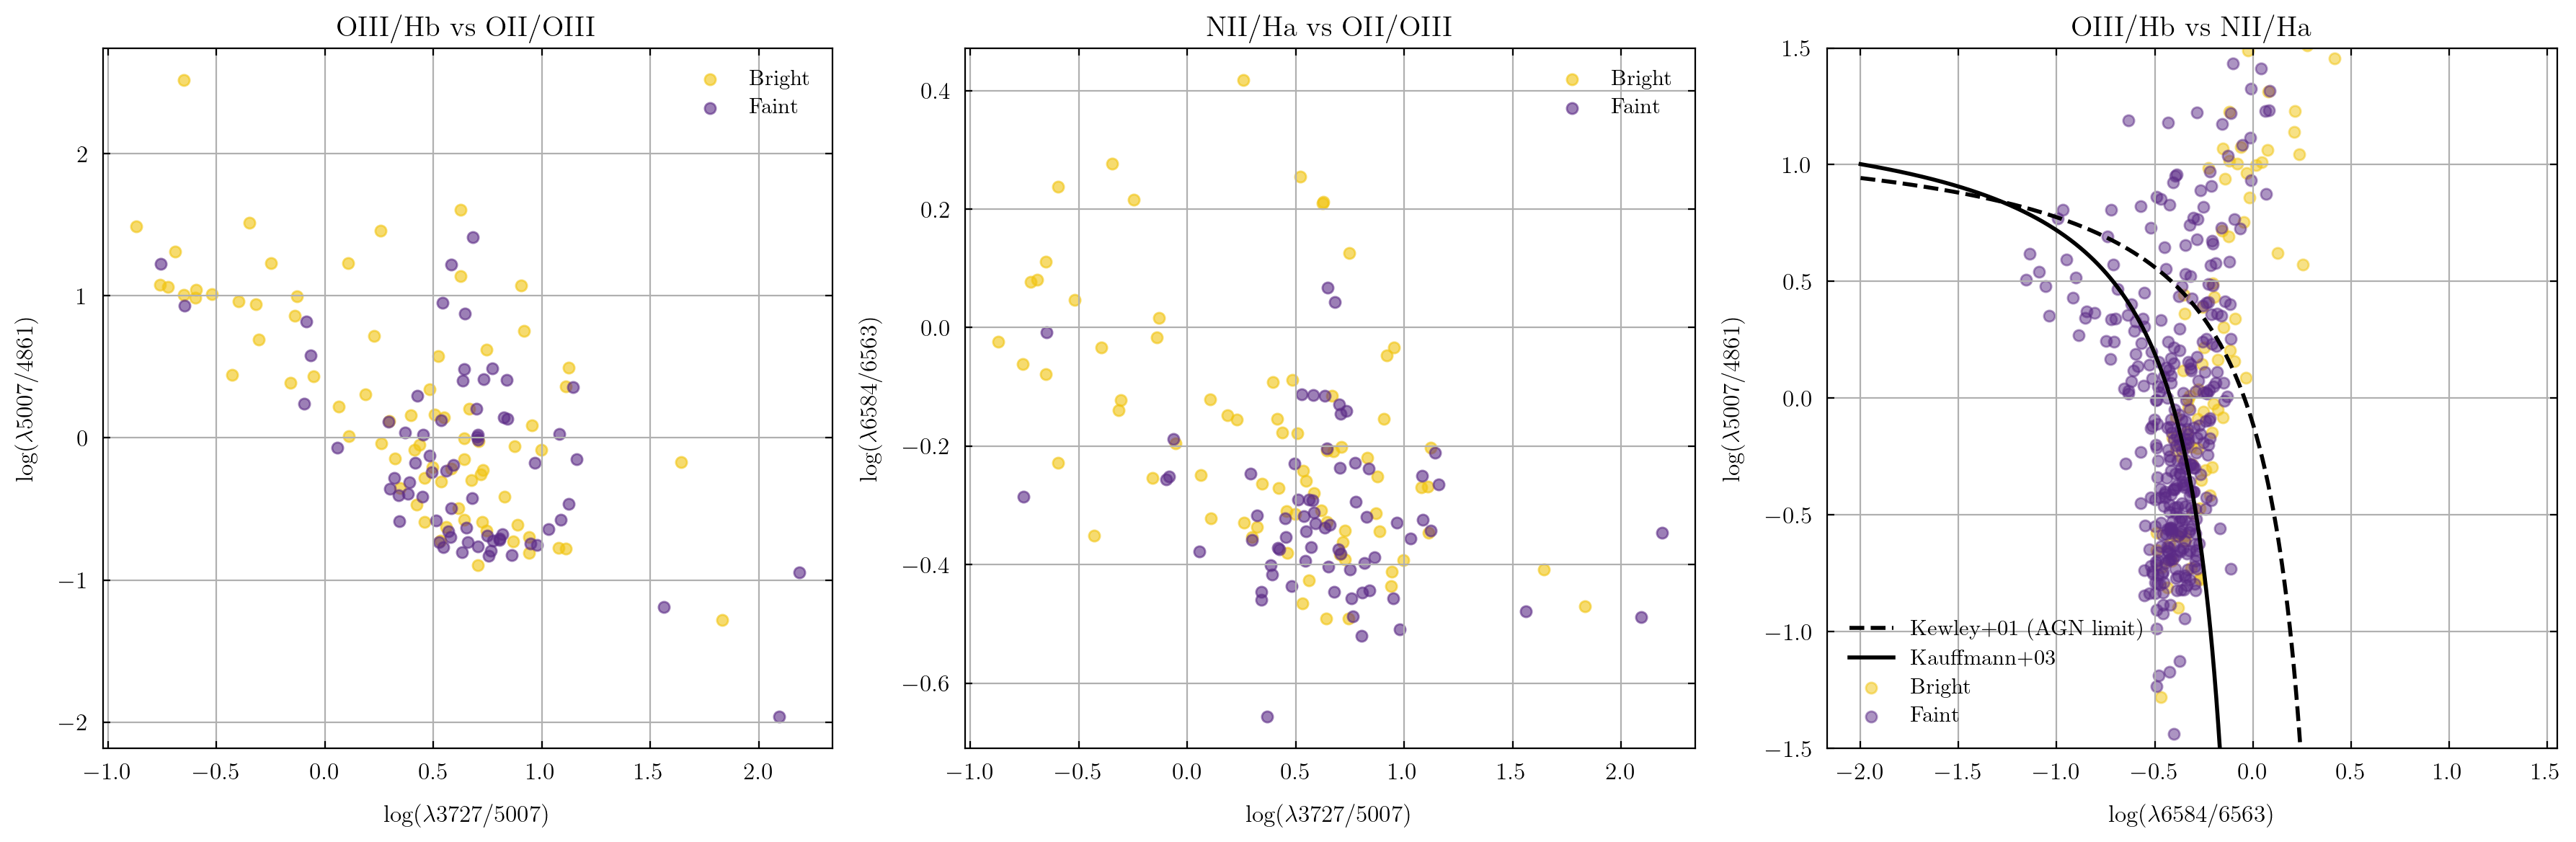

In [ ]:
def compute_line_ratios(wave, flux):
    Hb   = measure_line_flux(wave, flux, 4861)
    OIII = measure_line_flux(wave, flux, 5007)
    Ha   = measure_line_flux(wave, flux, 6563)
    NII  = measure_line_flux(wave, flux, 6584)
    OII  = measure_line_flux(wave, flux, 3727)

    Dn4000 = compute_Dn4000(wave, flux)
    HDelta = compute_HdeltaA(wave, flux)

    ratios = {}

    if np.abs(Hb) > 1e-3 and np.abs(Ha) > 1e-3 and np.abs(OIII) > 1e-3:
        ratios['OIII_Hb']   = np.log10(OIII / Hb)
        ratios['NII_Ha']    = np.log10(NII / Ha)
        ratios['OII_OIII']  = np.log10(OII / OIII)
        ratios['Dn4000']    = Dn4000
        ratios['HDeltaA']   = HDelta

    return ratios


# Collect ALL ratios per population
def get_ratios_for_population(spectra_list, max_gal=None):
    OIII_Hb_vals  = []
    NII_Ha_vals   = []
    OII_OIII_vals = []
    Dn4000 = []
    HDeltaA = []

    iterable = spectra_list if max_gal is None else spectra_list[:max_gal]

    for wave_rest, flux_rest in iterable:
        spec = process_spectrum_rest(wave_rest, flux_rest)
        if spec is None:
            continue

        ratios = compute_line_ratios(wave_grid, spec)

        if all(k in ratios for k in ['OIII_Hb', 'NII_Ha', 'OII_OIII']):
            OIII_Hb_vals.append(ratios['OIII_Hb'])
            NII_Ha_vals.append(ratios['NII_Ha'])
            OII_OIII_vals.append(ratios['OII_OIII'])
            Dn4000.append(ratios['Dn4000'])
            HDeltaA.append(ratios['HDeltaA'])

    return (np.array(OIII_Hb_vals), np.array(NII_Ha_vals), np.array(OII_OIII_vals), np.array(Dn4000), np.array(HDeltaA))


#  Get data
bright_OIIIHb, bright_NIIHa, bright_OIIOIII, bright_Dn4000, bright_HDelta = get_ratios_for_population(bright_spectra)
faint_OIIIHb,  faint_NIIHa,  faint_OIIOIII,  faint_Dn4000,  faint_HDelta  = get_ratios_for_population(faint_spectra)
blue_OIIIHb,   blue_NIIHa,   blue_OIIOIII,   blue_Dn4000,   blue_HDelta   = get_ratios_for_population(blue_spectra)
red_OIIIHb,    red_NIIHa,    red_OIIOIII,    red_Dn4000,    red_HDelta    = get_ratios_for_population(red_spectra)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)

def kewley01(x):
    return 0.61 / (x - 0.47) + 1.19

def kauffmann03(x):
    return 0.61 / (x - 0.05) + 1.3

x_vals_1 = np.linspace(-2.0, 0.5, 500)



ax = axes[0]
ax.scatter(bright_OIIOIII, bright_OIIIHb, s=30, alpha=0.6, label="Bright", color='#F1C40F')
ax.scatter(faint_OIIOIII,  faint_OIIIHb,  s=30, alpha=0.6, label="Faint",  color='#5B2A86')
#ax.scatter(blue_OIIOIII,   blue_OIIIHb,   s=30, alpha=0.3, label="Blue",   color='dodgerblue')
#ax.scatter(red_OIIOIII,    red_OIIIHb,    s=30, alpha=0.3, label="Red",    color='red')

ax.set_xlabel(r"log($\lambda 3727 / 5007$)")
ax.set_ylabel(r"log($\lambda 5007 / 4861$)")
ax.set_title(r"OIII/Hb vs OII/OIII")
ax.legend()
ax.grid(True)


# Panel 2
ax = axes[1]
ax.scatter(bright_OIIOIII, bright_NIIHa, s=30, alpha=0.6, label="Bright", color='#F1C40F')
ax.scatter(faint_OIIOIII,  faint_NIIHa,  s=30, alpha=0.6, label="Faint",  color='#5B2A86')
#ax.scatter(blue_OIIOIII,   blue_NIIHa,   s=30, alpha=0.3, label="Blue",   color='dodgerblue')
#ax.scatter(red_OIIOIII,    red_NIIHa,    s=30, alpha=0.3, label="Red",    color='red')

ax.set_xlabel(r"log($\lambda 3727 / 5007$)")
ax.set_ylabel(r"log($\lambda 6584 / 6563$)")
ax.set_title(r"NII/Ha vs OII/OIII")
ax.legend()
ax.grid(True)


# Panel 3
ax = axes[2]

x_vals_1 = np.linspace(-2.0, 0.0, 2000)
x_vals_2 = np.linspace(-2.0, 0.4, 500) 

ax.plot(x_vals_2, kewley01(x_vals_2), 'k--', lw=2, label='Kewley+01 (AGN limit)')
ax.plot(x_vals_1, kauffmann03(x_vals_1), 'k-', lw=2, label='Kauffmann+03')

ax.set_ylabel(r"log($\lambda 5007 / 4861$)")
ax.set_xlabel(r"log($\lambda 6584 / 6563$)")
ax.set_title(r"OIII/Hb vs NII/Ha (BPT)")
ax.legend()
ax.grid(True)
#ax.set_ylim(-1.5, .5)

ax.scatter(bright_NIIHa, bright_OIIIHb,   s=30, alpha=0.5, label="Bright",   color='#F1C40F')
ax.scatter(faint_NIIHa, faint_OIIIHb,        s=30, alpha=0.5, label="Faint",   color='#5B2A86')
#ax.scatter(blue_NIIHa, blue_OIIIHb,   s=30, alpha=0.3, label="Blue",   color='dodgerblue')
#ax.scatter(red_NIIHa, red_OIIIHb,        s=30, alpha=0.3, label="Red",    color='red')

ax.set_ylabel(r"log($\lambda 5007 / 4861$)")
ax.set_xlabel(r"log($\lambda 6584 / 6563$)")
ax.set_title(r"OIII/Hb vs NII/Ha")
ax.legend()
ax.grid(True)
ax.set_ylim(-1.5, 1.5)

plt.savefig('line_ratio_comparison_MAG.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

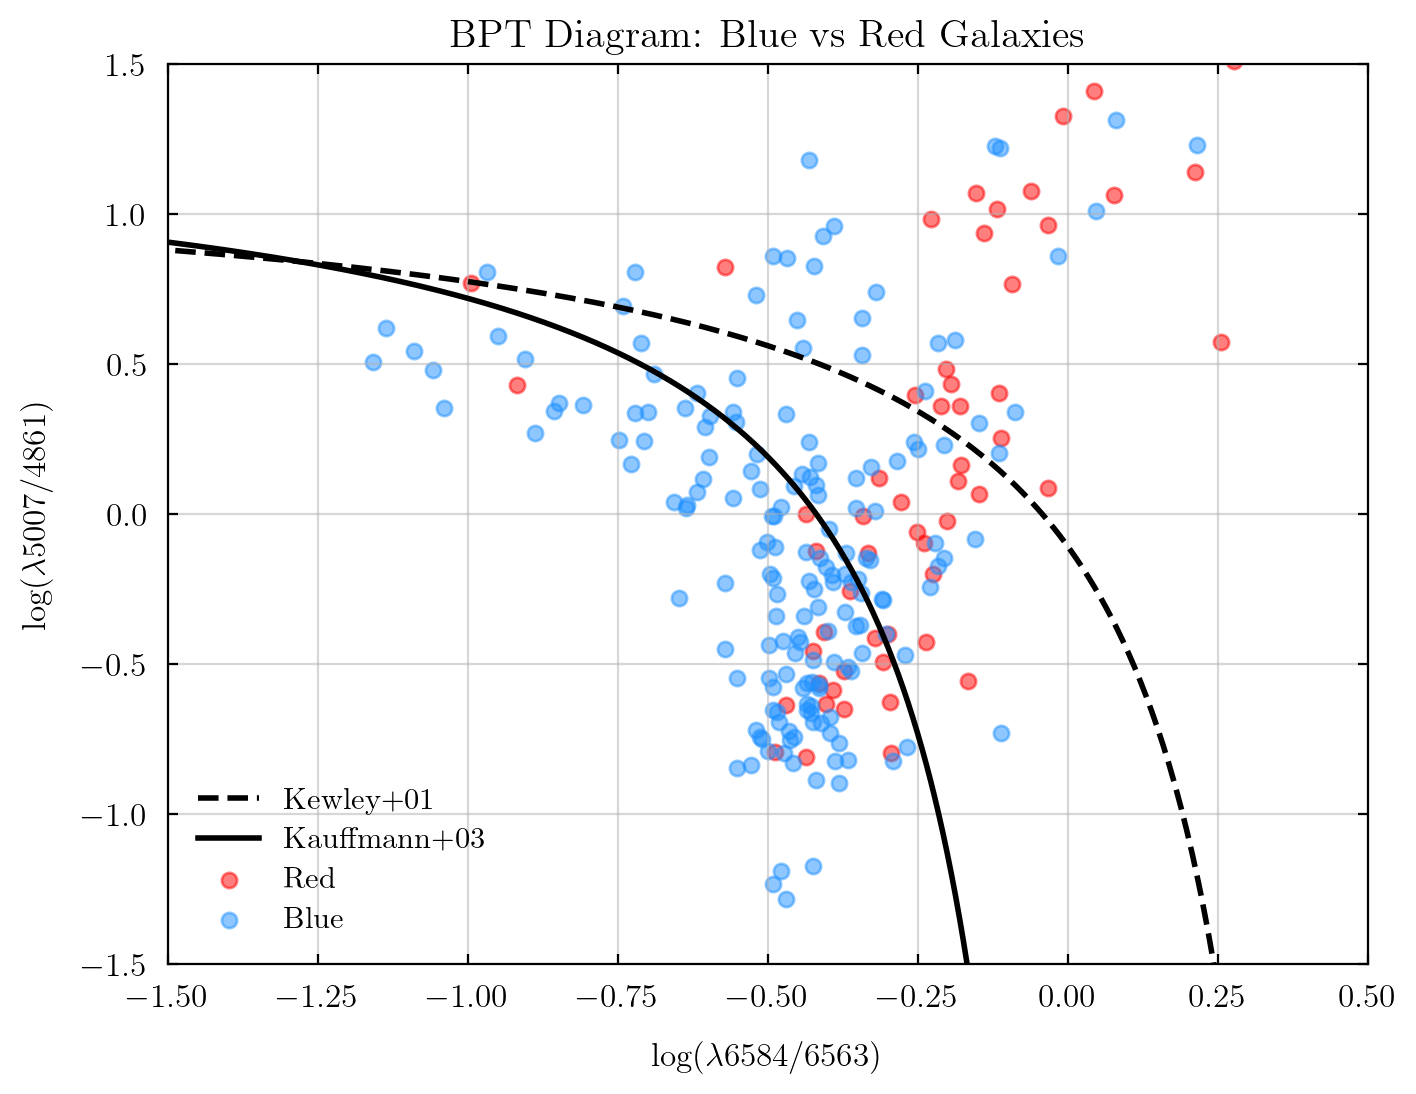

In [74]:
plt.figure(figsize=(8,6))
x_vals_1 = np.linspace(-2.0, 0.0, 2000)
x_vals_2 = np.linspace(-2.0, 0.4, 500) 

plt.plot(x_vals_2, kewley01(x_vals_2), 'k--', lw=2, label='Kewley+01')
plt.plot(x_vals_1, kauffmann03(x_vals_1), 'k-', lw=2, label='Kauffmann+03')

plt.grid(alpha = .5)
plt.scatter(red_NIIHa, red_OIIIHb,   s=30, alpha=0.5, label="Red",   color='red')
plt.scatter(blue_NIIHa, blue_OIIIHb,        s=30, alpha=0.5, label="Blue",   color='dodgerblue')
plt.ylabel(r"log($\lambda 5007 / 4861$)")
plt.ylim(-1.5, 1.5)
plt.xlabel(r"log($\lambda 6584 / 6563$)")
#plt.title(r"OIII/Hb vs NII/Ha")
plt.title("BPT Diagram: Blue vs Red Galaxies")
plt.legend()
plt.xlim(-1.5, 0.5)
plt.savefig('BPT_color_comparison.png', dpi=300, bbox_inches='tight')

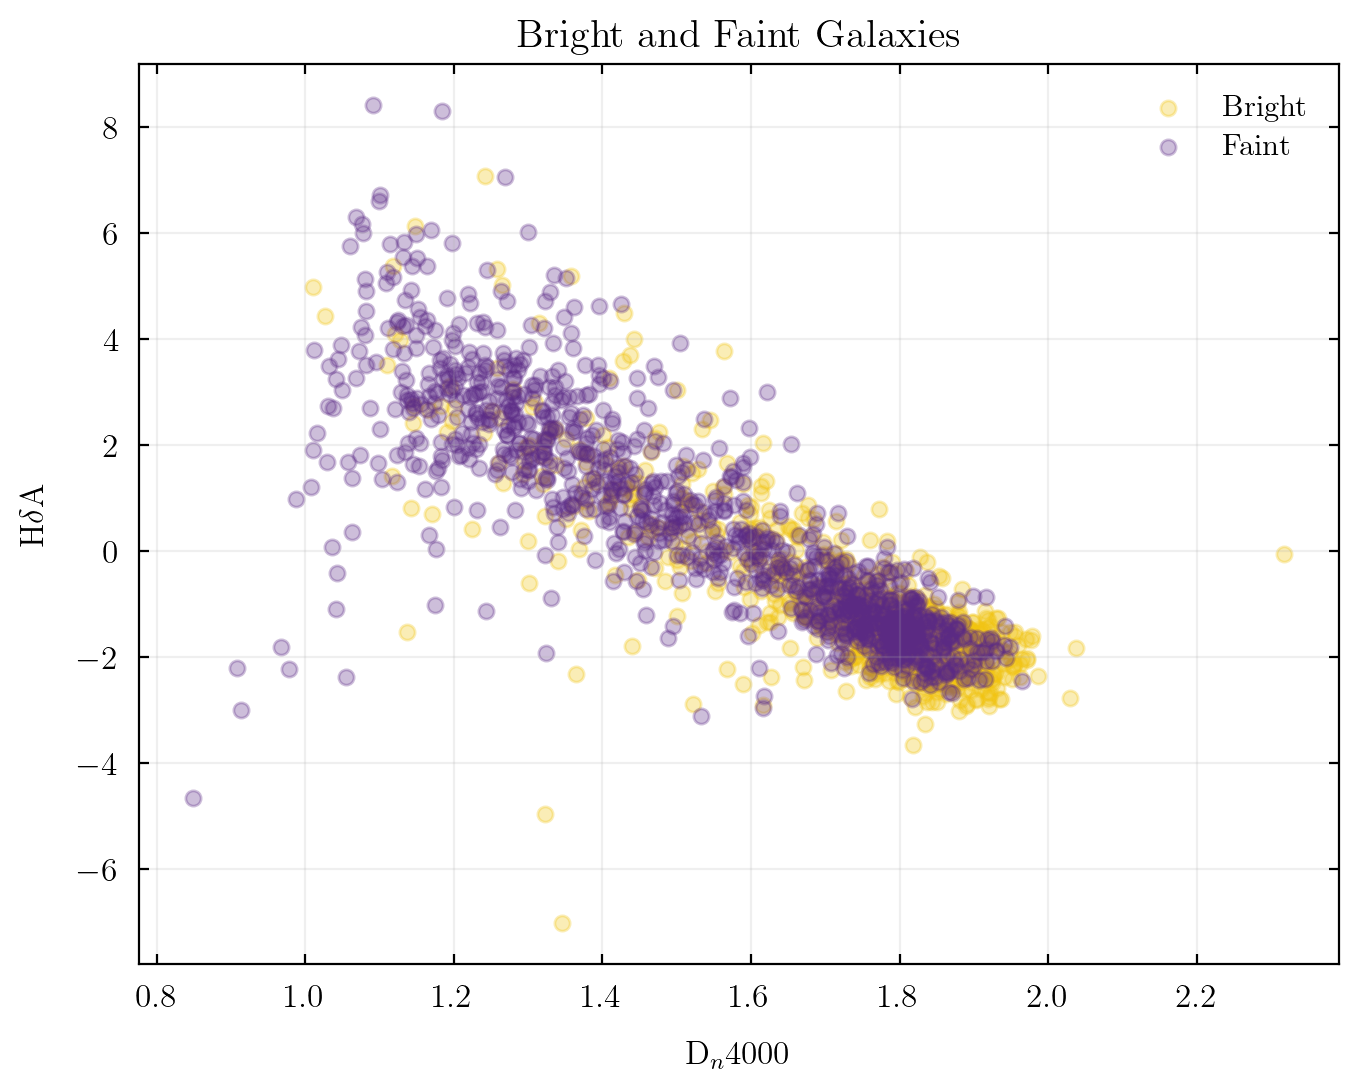

In [69]:
plt.figure(figsize=(8, 6))
plt.scatter(bright_Dn4000, bright_HDelta, s=30, alpha=0.3, label="Bright", color='#F1C40F')
plt.scatter(faint_Dn4000,  faint_HDelta,  s=30, alpha=0.3, label="Faint",  color='#5B2A86')
plt.xlabel("D$_n$4000")
plt.ylabel("H$\delta$A")
plt.title("Bright and Faint Galaxies")
plt.legend()
plt.grid(True, alpha = .2)
plt.savefig('Dn4000_Hdelta_comparison_Mag.png', dpi=300, bbox_inches='tight')
plt.show()

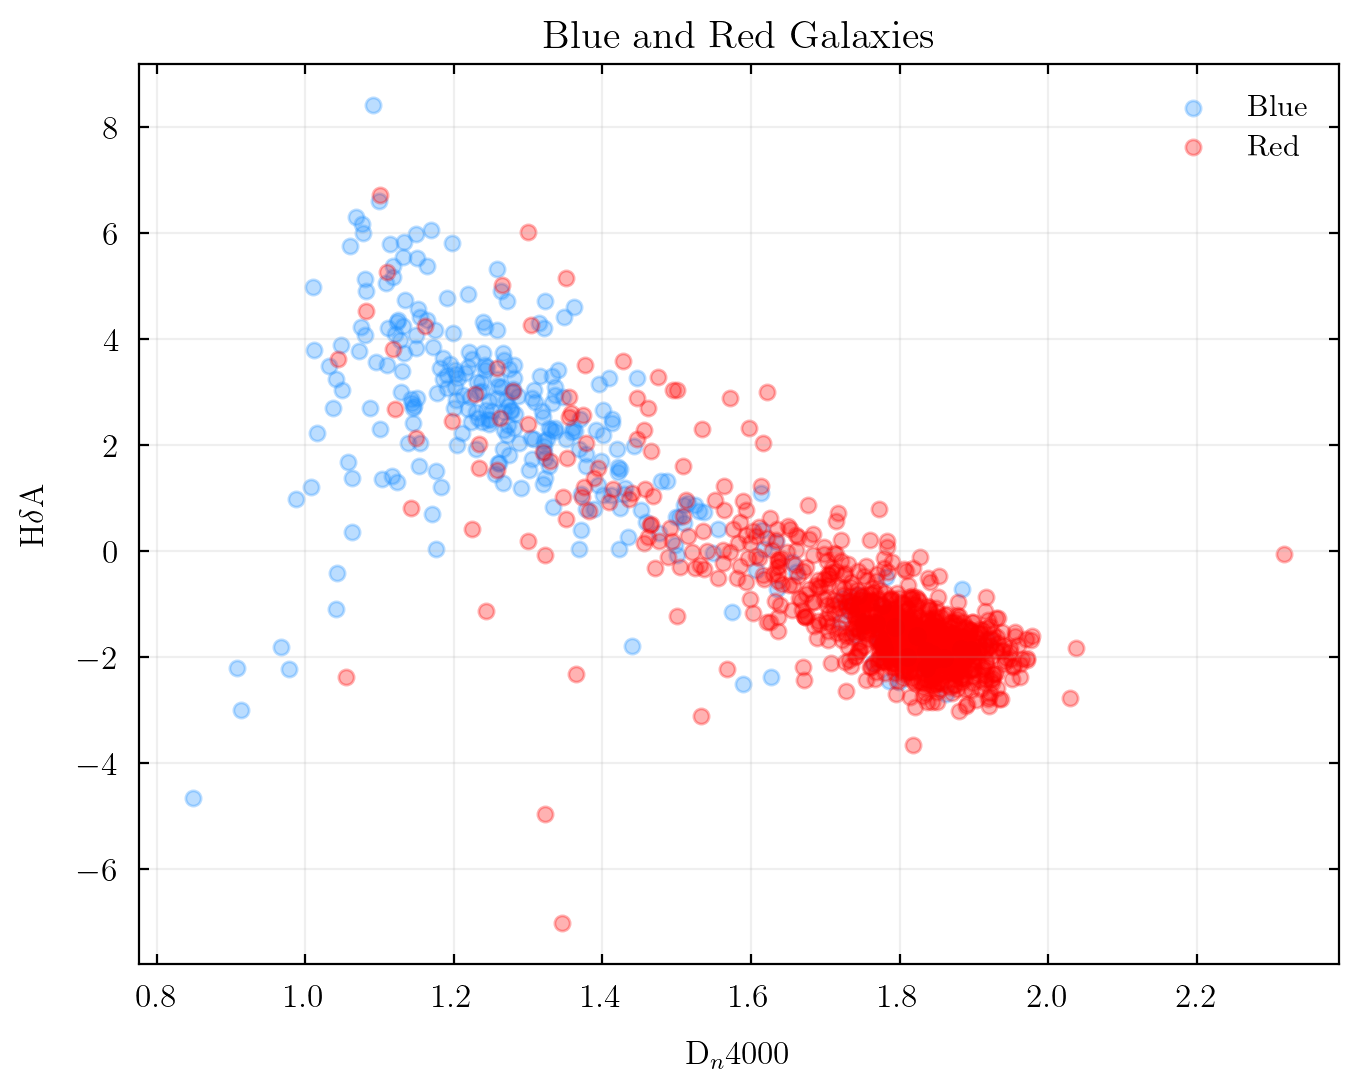

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(blue_Dn4000, blue_HDelta, s=30, alpha=0.3, label="Blue", color='dodgerblue')
plt.scatter(red_Dn4000, red_HDelta, s=30, alpha=0.3, label="Red", color='red')
plt.xlabel("D$_n$4000")
plt.ylabel("H$\delta$A")
plt.title("Blue and Red Galaxies")
plt.legend()
plt.grid(True, alpha = .2)
plt.savefig('Dn4000_Hdelta_comparison_Color.png', dpi=300, bbox_inches='tight')
plt.show()

Cut at M_r = -22
Bright galaxies (M_r < -22): 926
Faint galaxies (M_r ≥ -22): 1073
Bright bin: 926 galaxies total, 100 stacked
Faint bin:  1073 galaxies total, 100 stacked


/var/folders/lx/ftzs4lrn0cgbwjrztzt0n5w00000gn/T/ipykernel_1475/2400086844.py:40: RuntimeWarning: All-NaN slice encountered
  return np.nanmedian(np.array(stack), axis=0), used


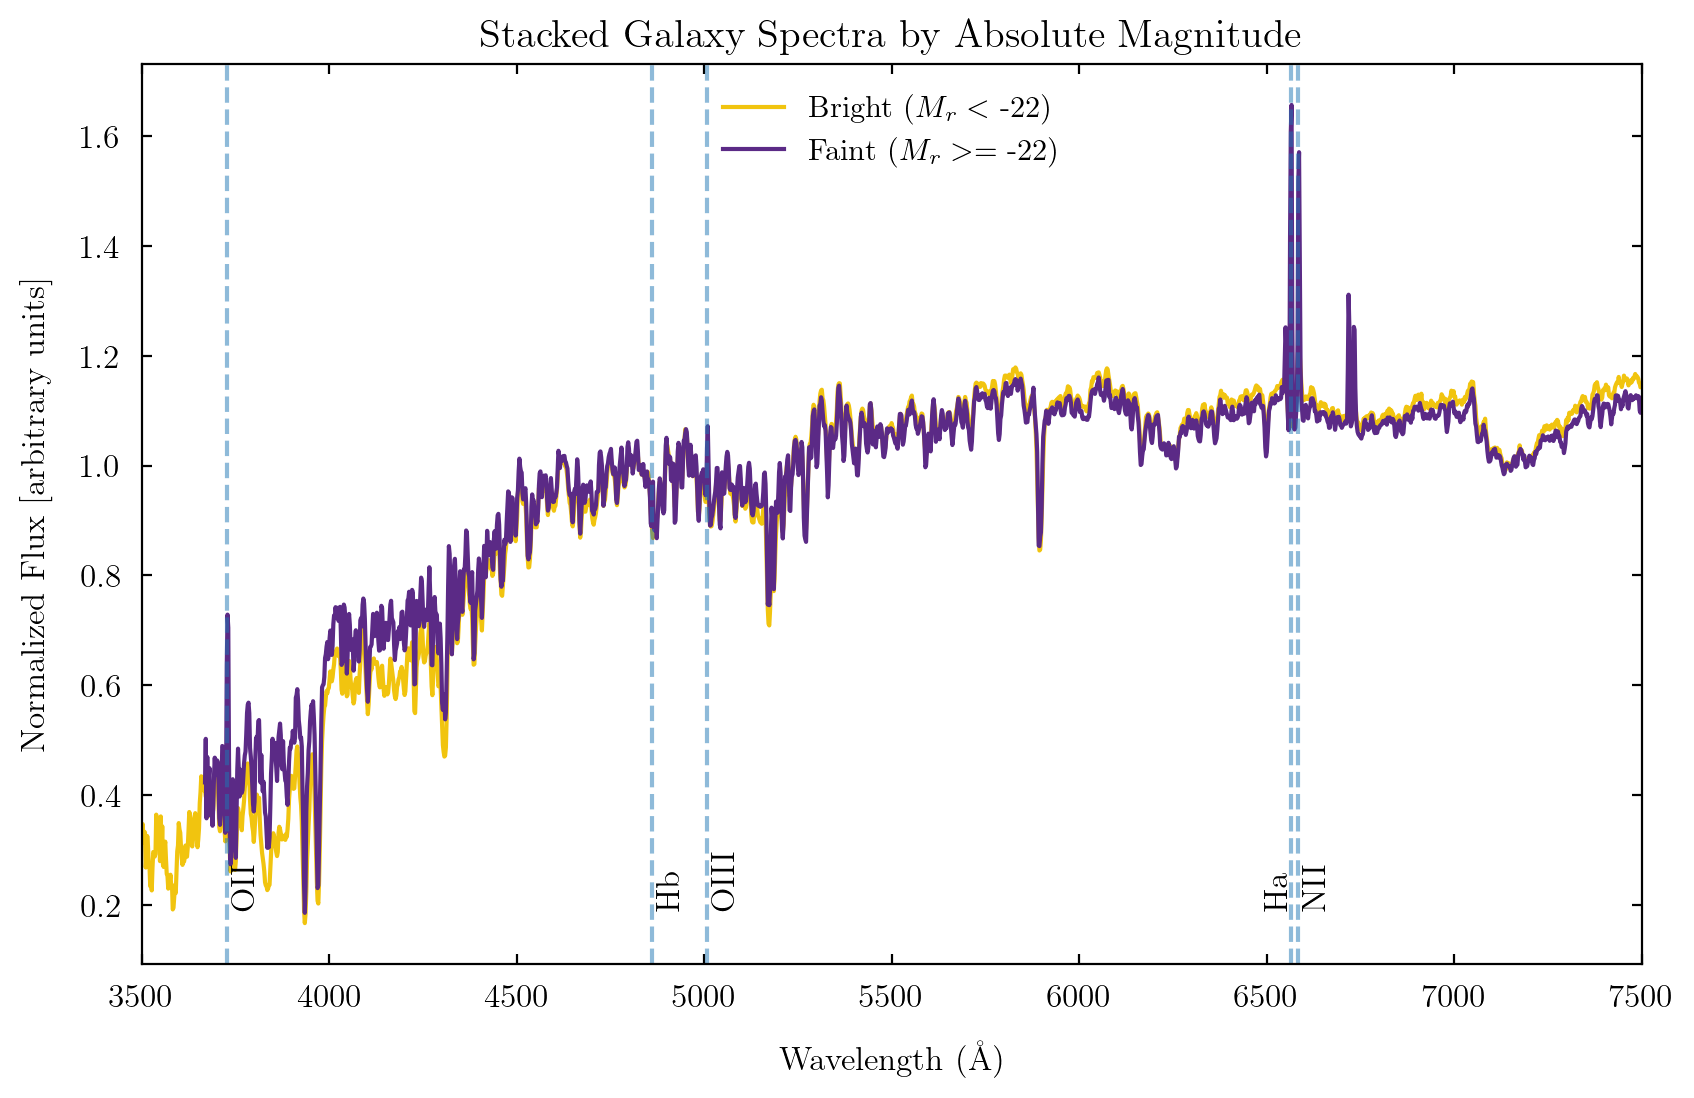

In [ ]:
bright_spectra = [
    rest_spectra[i]
    for i, Mr in enumerate(M_r_arr)
    if Mr < -22
]

faint_spectra = [
    rest_spectra[i]
    for i, Mr in enumerate(M_r_arr)
    if Mr >= -22
]


def stack_precomputed_with_count(spectra_list, max_gal=100):
    stack = []
    used = 0

    for wave_rest, flux_rest in spectra_list[:max_gal]:
        spec = process_spectrum_rest(wave_rest, flux_rest)

        if spec is not None:
            stack.append(spec)
            used += 1

    if len(stack) == 0:
        return None, 0

    return np.nanmedian(np.array(stack), axis=0), used


# Compute stacks + counts
bright_stack, bright_used = stack_precomputed_with_count(bright_spectra)
faint_stack, faint_used   = stack_precomputed_with_count(faint_spectra)


# Print counts
print(f"Bright bin: {len(bright_spectra)} galaxies total, {bright_used} stacked")
print(f"Faint bin:  {len(faint_spectra)} galaxies total, {faint_used} stacked")


# Plot spectra
plt.figure(figsize=(10,6))

if bright_stack is not None:
    plt.plot(wave_grid, bright_stack,
             label=f'Bright ($M_r <$ -22)', color="#F1C40F")

if faint_stack is not None:
    plt.plot(wave_grid, faint_stack,
             label=f'Faint ($M_r >=$ -22)', color='#5B2A86')


# Key spectral lines
lines = {
    "OII": 3727,
    "Hb": 4861,
    "OIII": 5007,
}

for name, wl in lines.items():
    plt.axvline(wl, linestyle='--', alpha=0.5)
    plt.text(wl + 10, 0.2, name, rotation=90)

plt.axvline(6563, linestyle='--', alpha=0.5)
plt.text(6563 - 70, 0.2, 'Ha', rotation=90)

plt.axvline(6584, linestyle='--', alpha=0.5)
plt.text(6584 + 10, 0.2, 'NII', rotation=90)


plt.xlabel('Wavelength (Å)')
plt.ylabel('Normalized Flux [arbitrary units]')
plt.title('Stacked Galaxy Spectra by Absolute Magnitude')
plt.legend()
plt.xlim(3500, 7500)
plt.savefig('stacked_spectra_magnitude_bins.png', dpi=300, bbox_inches='tight')

plt.show()

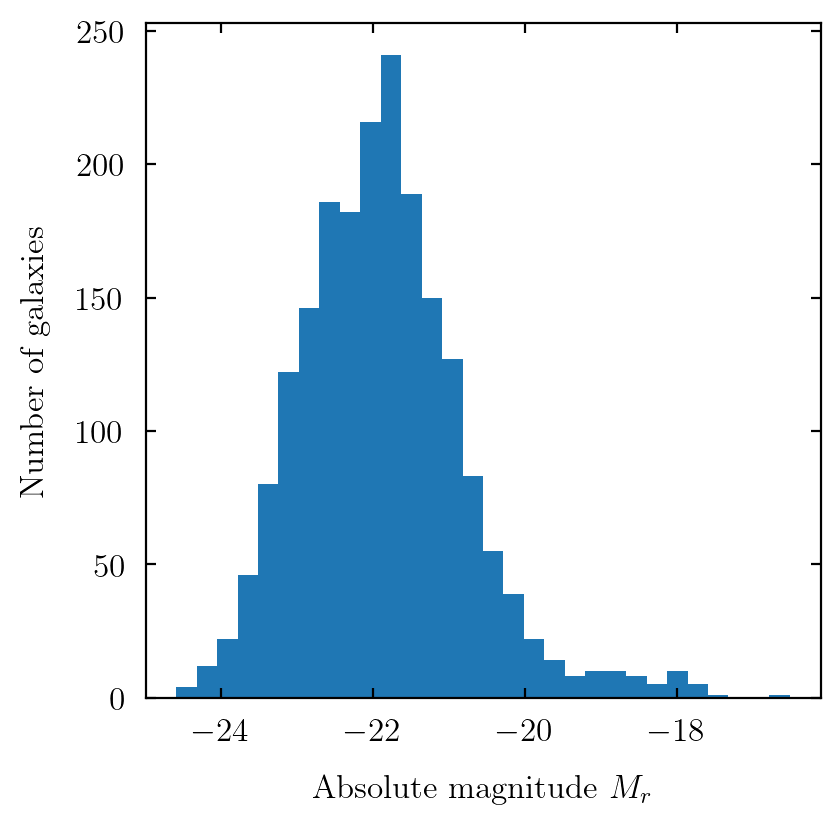

In [58]:
plt.hist(M_r_arr_no_max, bins=30)
plt.xlabel("Absolute magnitude $M_r$")
plt.ylabel("Number of galaxies")
plt.savefig('magnitude_histogram.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
print(np.max(M_r_arr))
print(np.min(M_r_arr))

155942423467.0497
-24.589391872187335


In [48]:
M_r_arr_no_max = M_r_arr[M_r_arr != np.max(M_r_arr)]

In [57]:
print(np.max(M_r_arr_no_max))

-16.514063861652687


In [56]:
M_r_arr_no_max = M_r_arr_no_max[M_r_arr_no_max != np.max(M_r_arr_no_max)]

In [ ]:
pri